<a href="https://colab.research.google.com/github/bashirun-008/plantdisease_prediction/blob/main/plant_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import files
files.upload()  # Upload your kaggle.json file here

Saving kaggle (3).json to kaggle (3).json


{'kaggle (3).json': b'{"username":"mdbashirunsultana","key":"c1407fde762d036547ce500332d23d1c"}'}

In [16]:
# Rename the file to exactly kaggle.json
!mv "kaggle (3).json" kaggle.json

# Create the hidden kaggle directory and move the file there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key successfully configured!")

Kaggle API key successfully configured!


In [17]:
# Clear old extracted data first
!rm -rf plant_data plantdisease.zip

In [18]:
# 3. Download and unzip the PlantVillage dataset
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plant_data
print("Dataset downloaded and unzipped!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:33<00:00, 20.8MB/s]

Dataset downloaded and unzipped!


In [19]:
# 4. Set the correct data directory
DATA_DIR = "plant_data/PlantVillage"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Loaded {len(class_names)} classes: {class_names}")

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Loaded 15 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [20]:
# 5. Data augmentation + performance optimization
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
print("Augmentation and prefetching set up!")

Augmentation and prefetching set up!


In [21]:
# 6. Build the model with MobileNetV2 transfer learning
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# 7. Fast Model Training (3 Epochs)
EPOCHS = 3

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/3
516/516 ━━━━━━━━━━━━━━━━━━━━ 352s 614ms/step - accuracy: 0.7092 - loss: 0.9219 - val_accuracy: 0.8163 - val_loss: 0.5843
Epoch 2/3
516/516 ━━━━━━━━━━━━━━━━━━━━ 254s 492ms/step - accuracy: 0.8353 - loss: 0.5142 - val_accuracy: 0.8546 - val_loss: 0.4682
Epoch 3/3
516/516 ━━━━━━━━━━━━━━━━━━━━ 255s 494ms/step - accuracy: 0.8534 - loss: 0.4424 - val_accuracy: 0.8612 - val_loss: 0.4438


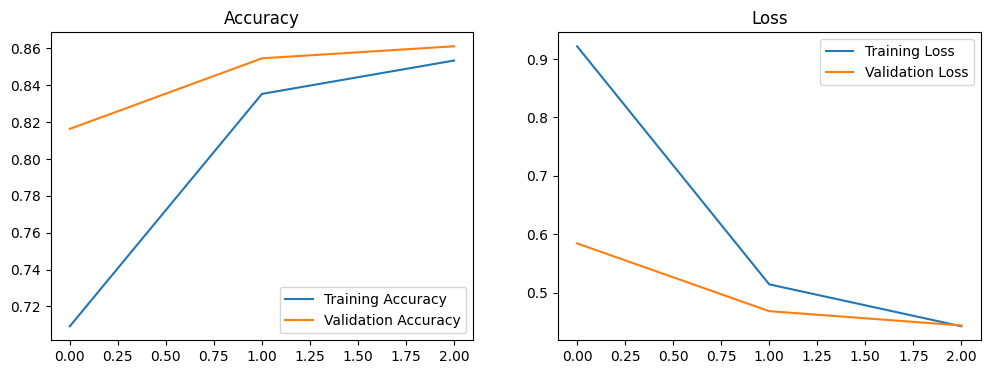

In [23]:
# 8. Plot training curves
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')

plt.savefig('training_curves.png')
plt.show()

In [24]:
# 9. Print final results
final_val_acc = val_acc[-1]
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")

Final Validation Accuracy: 86.12%


In [25]:
# 10. Save the trained model
model.save('plant_disease_model.h5')
print("Model saved!")

Model saved!
